# GPT-2 Sentiment Analysis — NLP Project

---

### What we're building

A program that reads movie reviews and predicts their **sentiment** (how positive or negative they are).

### How it works

1. We take **GPT-2** (a pre-trained language model from OpenAI that already understands English)
2. We add a small **classifier head** on top (a simple layer that makes the final prediction)
3. We train it on labeled movie reviews

### Two approaches

| Approach | What it means | Accuracy | Speed |
|----------|---------------|----------|-------|
| **Frozen** | GPT-2 stays locked, we only train the classifier head | Lower (~45% on SST) | Fast (~5 min) |
| **Fine-tuning** | We update ALL of GPT-2's weights during training | Higher (~52% on SST) | Slow (~30-60 min) |

### Two datasets

| Dataset | Type of text | Classes |
|---------|-------------|---------|
| **SST** (Stanford Sentiment Treebank) | Short sentences (~19 words) | 5 (very negative → very positive) |
| **CFIMDB** (IMDB reviews) | Full reviews (~192 words) | 2 (positive, negative) |

---

## Section 1: Setup & Environment

First, we import all the libraries we need and check that everything is working.

### What each library does:
- **`torch`** — PyTorch, the deep learning framework that runs our model
- **`transformers`** — HuggingFace library that gives us GPT-2 (pre-trained and ready to use)
- **`pytreebank`** — Parses the SST dataset's tree format
- **`pandas`** — Data manipulation (like Excel for Python)
- **`matplotlib` / `seaborn`** — Making graphs
- **`scikit-learn`** — Metrics (accuracy, confusion matrix)
- **`tqdm`** — Progress bars (so we can see training progress)

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import GPT2Tokenizer, GPT2Model
import pytreebank
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
import os
import re
import sys
from pathlib import Path
# Ensure project root is cwd and on sys.path
project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
    os.chdir(str(project_root))
sys.path.insert(0, str(project_root))
from src.dataset import load_sst_data, load_cfimdb_data, SentimentDataset
from src.model import GPT2Classifier
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

# Check PyTorch version and CUDA availability
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Performance tweaks for RTX 4060
torch.set_float32_matmul_precision("high")  # TF32 Tensor Cores
torch.backends.cudnn.benchmark = True  # Auto-tune kernels
print(f'Using device: {device}')

/home/abosaleh/.pyenv/versions/3.14.4/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!
PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB
Using device: cuda


In [2]:
# Verify dataset files exist
sst_path = './data/Datasets/SST2Data/trainDevTestTrees_PTB/trees/train.txt'
cfimdb_path = './data/Datasets/CFIMDB_CS224N/ids-cfimdb-train.csv'

print(f'SST train file exists: {os.path.exists(sst_path)}')
print(f'CFIMDB train file exists: {os.path.exists(cfimdb_path)}')

if not os.path.exists(sst_path):
    print('WARNING: SST data not found! Check your dataset location.')
if not os.path.exists(cfimdb_path):
    print('WARNING: CFIMDB data not found! Check your dataset location.')

SST train file exists: True
CFIMDB train file exists: True


## Section 2: Load & Explore the SST Dataset

The **SST (Stanford Sentiment Treebank)** dataset contains movie review sentences. Each sentence is labeled with a sentiment from 0 (very negative) to 4 (very positive).

The data comes in a special tree format (Penn Treebank style). Each sentence is stored as a nested structure:
```
(3 (2 The) (4 movie))   ← means: the sentence "The movie" has label 3 (positive)
```
We'll use `pytreebank` to parse this into a simple table (DataFrame).

In [3]:
sst_df = load_sst_data()
print(f'SST dataset loaded: {len(sst_df)} total examples')
print(f'Split sizes:')
print(sst_df['split'].value_counts().to_string())
print(f'\nFirst 5 rows:')
print(sst_df.head())

SST dataset loaded: 11855 total examples
Split sizes:
split
train    8544
test     2210
dev      1101

First 5 rows:
                                                text  label  split
0  The Rock is destined to be the 21st Century 's...      3  train
1  The gorgeously elaborate continuation of `` Th...      4  train
2  Singer/composer Bryan Adams contributes a slew...      3  train
3  You 'd think by now America would have had eno...      2  train
4               Yet the act is still charming here .      3  train


=== SST Label Distribution (Training Set) ===
  0 (Very Negative):  1092 examples (12.8%)
  1 (Negative):  2218 examples (26.0%)
  2 (Neutral):  1624 examples (19.0%)
  3 (Positive):  2322 examples (27.2%)
  4 (Very Positive):  1288 examples (15.1%)

=== Sentence Length Statistics ===
  Average: 19.2 words
  Shortest: 2 words
  Longest: 56 words


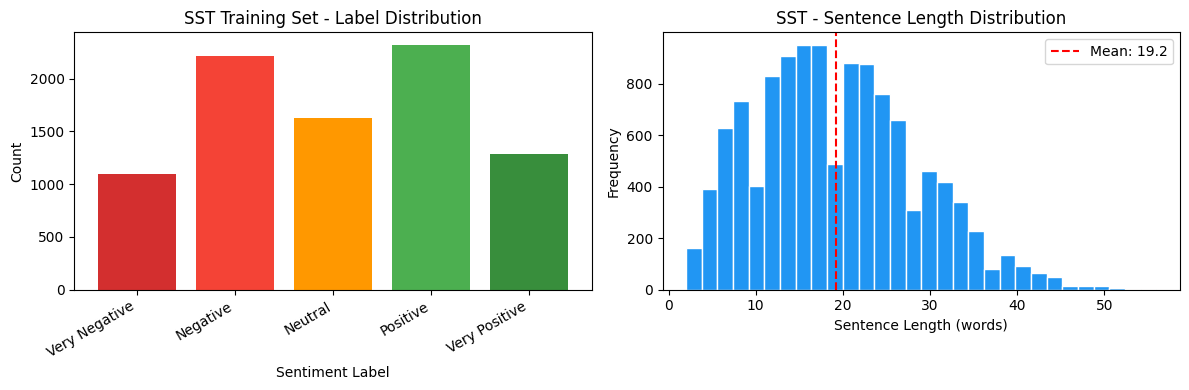


=== Example Sentences ===
  [0] Very Negative   → "... a sour little movie at its core ; an exploration of the emptiness that underlay the relentless gaiety of the 1920 's ... The film 's ending has a `` What was it all for ? ''"
  [1] Negative        → "This is n't a new idea ."
  [2] Neutral         → "You 'd think by now America would have had enough of plucky British eccentrics with hearts of gold ."
  [3] Positive        → "The Rock is destined to be the 21st Century 's new `` Conan '' and that he 's going to make a splash even greater than Arnold Schwarzenegger , Jean-Claud Van Damme or Steven Segal ."
  [4] Very Positive   → "The gorgeously elaborate continuation of `` The Lord of the Rings '' trilogy is so huge that a column of words can not adequately describe co-writer/director Peter Jackson 's expanded vision of J.R.R. Tolkien 's Middle-earth ."


In [4]:
# Analyze label distribution and sentence lengths
label_names = {0: 'Very Negative', 1: 'Negative', 2: 'Neutral', 3: 'Positive', 4: 'Very Positive'}

print('=== SST Label Distribution (Training Set) ===')
train_sst = sst_df[sst_df['split'] == 'train']
label_counts = train_sst['label'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f'  {label} ({label_names[label]}): {count:5d} examples ({count/len(train_sst)*100:.1f}%)')

# Sentence length analysis
sst_df['word_count'] = sst_df['text'].str.split().str.len()
print(f'\n=== Sentence Length Statistics ===')
print(f'  Average: {sst_df["word_count"].mean():.1f} words')
print(f'  Shortest: {sst_df["word_count"].min()} words')
print(f'  Longest: {sst_df["word_count"].max()} words')

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of labels
colors = ['#d32f2f', '#f44336', '#ff9800', '#4caf50', '#388e3c']
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Count')
axes[0].set_title('SST Training Set - Label Distribution')
axes[0].set_xticks(list(label_names.keys()))
axes[0].set_xticklabels(list(label_names.values()), rotation=30, ha='right')

# Histogram of sentence lengths
axes[1].hist(sst_df['word_count'], bins=30, color='#2196f3', edgecolor='white')
axes[1].set_xlabel('Sentence Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('SST - Sentence Length Distribution')
axes[1].axvline(sst_df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {sst_df["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show some example sentences
print('\n=== Example Sentences ===')
for label in range(5):
    example = sst_df[sst_df['label'] == label]['text'].iloc[0]
    print(f'  [{label}] {label_names[label]:15s} → "{example}"')

## Section 3: Load & Explore the CFIMDB Dataset

The **CFIMDB** dataset contains movie reviews from IMDB. Each review is labeled as either 'positive' or 'negative'. The dataset is the official CS224N Default Project subset:
- Train: 1,701 examples
- Dev: 245 examples
- Test: 488 examples

The reviews are much longer than SST sentences (~192 words vs ~19 words). This matters because GPT-2 can only handle up to 1024 tokens at once.

In [5]:
cfimdb_df = load_cfimdb_data()
print(f'CFIMDB dataset loaded: {len(cfimdb_df)} total examples')
print(f'Split sizes:')
print(cfimdb_df['split'].value_counts().to_string())
print(f'\nFirst 3 rows:')
print(cfimdb_df.head(3))

CFIMDB dataset loaded: 2440 total examples
Split sizes:
split
train    1707
test      488
dev       245

First 3 rows:
                                                text  label  split
0   I was never quite sure where this thing was g...      1  train
1   """ I vaguely remember Ben from my Sci - Fi f...      1  train
2   Possibly not , but it is great . Even the fan...      1  train


In [6]:
# Analyze CFIMDB dataset
import numpy as np
print('=== CFIMDB Label Distribution ===')
print(cfimdb_df.groupby('split')['label'].value_counts().unstack(fill_value=0))

cs224n_valid = cfimdb_df[cfimdb_df['label'] != -1]
cs224n_valid['word_count'] = cs224n_valid['text'].str.split().str.len()
print(f'\n=== Review Length Statistics ===')
print(f'  Average: {cs224n_valid["word_count"].mean():.0f} words')
print(f'  Shortest: {cs224n_valid["word_count"].min()} words')
print(f'  Longest: {cs224n_valid["word_count"].max()} words')

=== CFIMDB Label Distribution ===
label   -1    0    1
split               
dev      0  123  122
test   488    0    0
train    0  856  851

=== Review Length Statistics ===
  Average: 191 words
  Shortest: 18 words
  Longest: 418 words


## Section 4: Tokenization & DataLoaders

### What is tokenization?

Computers don't understand words — they understand **numbers**. Tokenization is the process of converting text into numbers (called **token IDs**) that the model can process.

GPT-2 uses **Byte-Pair Encoding (BPE)**. It splits text into smaller pieces:
```
"The movie was fantastic!" → [464, 3181, 373, 35715, 0]
```

### How data flows

| Component | File | Role |
|---|---|---|
| `SentimentDataset` | `dataset.py` | Loads & pre-tokenizes all text once at init — no per-item tokenizer calls |
| `load_sst_data()` | `dataset.py` | Parses SST tree files into a DataFrame |
| `load_cfimdb_data()` | `dataset.py` | Loads IMDB CSV, cleans HTML, creates train/dev/test splits |
| `DataLoader` | (PyTorch) | Feeds batches to the model with 6 parallel workers |

Both the notebook and `train.py` import from `dataset.py`, so there's a single source of truth for data loading.


In [7]:
# Load GPT-2 tokenizer
model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# GPT-2 doesn't have a padding token by default (padding = making all sentences the same length)
# We'll use the end-of-sequence token as the padding token
tokenizer.pad_token = tokenizer.eos_token

# Test it on a sample sentence
test_text = 'The The movie was fantastic!'
tokens = tokenizer(test_text, return_tensors='pt')
print(f'Original text: "{test_text}"')
print(f'Token IDs: {tokens["input_ids"][0].tolist()}')
print(f'Decoded back: "{tokenizer.decode(tokens["input_ids"][0])}"')
print(f'Number of tokens: {len(tokens["input_ids"][0])}')

# Check how many tokens each dataset needs
sst_tokens = sst_df['text'].apply(lambda x: len(tokenizer.encode(x)))
cfimdb_tokens = cfimdb_df['text'].apply(lambda x: len(tokenizer.encode(x)))

print(f'\n=== Token Length Analysis ===')
print(f'SST  - Max: {sst_tokens.max()}, Avg: {sst_tokens.mean():.0f} tokens')
print(f'CFIMDB - Max: {cfimdb_tokens.max()}, Avg: {cfimdb_tokens.mean():.0f} tokens')

# How many CFIMDB reviews exceed GPT-2's limit of 1024 tokens?
over_limit = (cfimdb_tokens > 1024).sum()
print(f'CFIMDB reviews exceeding 1024 tokens: {over_limit} ({over_limit/len(cfimdb_df)*100:.1f}%)')

Original text: "The The movie was fantastic!"
Token IDs: [464, 383, 3807, 373, 9623, 0]
Decoded back: "The The movie was fantastic!"
Number of tokens: 6

=== Token Length Analysis ===
SST  - Max: 61, Avg: 22 tokens
CFIMDB - Max: 494, Avg: 214 tokens
CFIMDB reviews exceeding 1024 tokens: 0 (0.0%)


In [8]:
# SentimentDataset is in dataset.py - imported by train.py subprocess
from src.dataset import SentimentDataset

# Quick test: one batch
test_ds = SentimentDataset(sst_df[sst_df["split"] == "train"].head(4), tokenizer, 128)
batch = test_ds[0]
print('DataLoader test passed!')
print(f'input_ids: {batch['input_ids'].shape}, attention_mask: {batch['attention_mask'].shape}, label: {batch['label']}')


DataLoader test passed!
input_ids: torch.Size([128]), attention_mask: torch.Size([128]), label: 3


## Section 5: GPT-2 Model Architecture

### How does the model work?

1. **Input**: Token IDs → fed into GPT-2
2. **Processing**: GPT-2's 12 transformer layers produce a **hidden state** (768-dim vector) per token
3. **Pooling**: Take the **last non-padding token's** hidden state — it has "seen" all previous tokens
4. **Classification**: Hidden state → dropout → linear layer → class scores (logits)

### Model registry (`model.py`)

All models live in `model.py` and are registered in `MODEL_REGISTRY`:
```python
MODEL_REGISTRY = {
    'baseline': GPT2Classifier,    # standard frozen/finetune
    # 'my_innovation': MyModel,    # <-- add yours here
}
```
To use a different model: `--model my_innovation` in `train.py`.

### Frozen vs Fine-tuning

| Mode | GPT-2 weights | Classifier weights | Trainable params |
|------|---------------|--------------------|------------------|
| **Frozen** | ❌ Locked | ✅ Trained | ~3,845 (0.003%) |
| **Fine-tuning** | ✅ Trained | ✅ Trained | ~124M (100%) |


In [9]:
# GPT2Classifier is imported from model.py

# Test the model with dummy input
print('=== Testing Model Forward Pass ===')
model_frozen = GPT2Classifier(num_classes=5, freeze=True).to(device)

dummy_input = torch.randint(0, 50000, (2, 10))  # (batch=2, seq_len=10)
dummy_mask = torch.ones(2, 10, dtype=torch.long)

with torch.no_grad():
    logits = model_frozen(dummy_input.to(device), dummy_mask.to(device))

print(f'Input shape: {dummy_input.shape}')
print(f'Output shape: {logits.shape}')  # (2, 5) — 2 samples, 5 class scores
print(f'Output (logits):\n{logits}')

# Count parameters
trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_frozen.parameters())
print(f'\nTrainable params: {trainable:,} / {total:,} ({trainable/total*100:.4f}%)')

=== Testing Model Forward Pass ===


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1288.43it/s]


  Mode: FROZEN — Only classifier head will be trained
Input shape: torch.Size([2, 10])
Output shape: torch.Size([2, 5])
Output (logits):
tensor([[ 1.9827,  4.6281,  0.6116, -7.5721,  4.3607],
        [-1.2029,  3.2107, -0.6848, -5.3171,  6.4733]], device='cuda:0')

Trainable params: 3,845 / 124,443,653 (0.0031%)


In [10]:
# Compare: fine-tuning mode (all parameters trainable)
print('=== Model with Fine-Tuning Mode ===')
model_unfrozen = GPT2Classifier(num_classes=5, freeze=False)

trainable_ft = sum(p.numel() for p in model_unfrozen.parameters() if p.requires_grad)
total_ft = sum(p.numel() for p in model_unfrozen.parameters())
print(f'Trainable params: {trainable_ft:,} / {total_ft:,} ({trainable_ft/total_ft*100:.4f}%)')
print(f'Additional params for fine-tuning: {trainable_ft - trainable:,}')

=== Model with Fine-Tuning Mode ===


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1762.20it/s]

  Mode: FINE-TUNING — All GPT-2 weights will be updated
Trainable params: 124,443,653 / 124,443,653 (100.0000%)
Additional params for fine-tuning: 124,439,808


## Section 6: Training Functions

Training logic lives in `src/train.py`, called from the notebook via `!python` subprocesses.
This keeps the notebook clean and allows full CPU multiprocessing (6 workers).

### Key functions in `src/train.py`

| Function | What it does |
|---|---|
| `train_one_epoch()` | One pass through the training set, updates weights |
| `evaluate()` | Run the model on dev/test without gradient computation |
| `make_loaders()` | Creates DataLoaders with 6 workers + pin_memory + prefetch |
| `main()` | Parses args, loads data, creates model, runs train/eval loop |

### Key concepts

- **Loss**: Cross-entropy — measures prediction error
- **Optimizer**: AdamW — adaptive learning rate with weight decay
- **Learning rate**: Frozen = 3e-3 (big steps), Fine-tuning = 5e-5 (small steps)
- **Scheduler**: Linear warmup + decay (fine-tuning only)
- **Gradient clipping**: Caps gradients at 1.0 to prevent explosions (fine-tuning only)
- **Mixed precision FP16**: Enabled for fine-tuning on RTX 4060 Tensor Cores

### Results are persisted

After each experiment, `src/train.py` saves `results/<name>.json` containing:
- `best_dev`: best dev accuracy across epochs
- `test_acc`: final test accuracy
- `history`: per-epoch train/dev loss + accuracy

The notebook loads these on re-run — no need to re-train to see old results.


## Section 7: Run Frozen Baseline Experiments

Each cell below calls `!python -m src.train ...` in a subprocess.
The subprocess has its own multiprocessing workers, so no BrokenPipeError.

### Hyperparameters

| Parameter | SST | CFIMDB |
|---|---|---|
| Batch size | 64 | 32 |
| Max length | 128 | 512 |
| Learning rate | 3e-3 | 3e-3 |
| Epochs | 10 | 5 |
| Workers | 6 | 6 |
| Model | `baseline` | `baseline` |

Results save to `results/sst_frozen.json` and `results/cfimdb_frozen.json`.


In [11]:
# Run SST Frozen Baseline
print('='*60)
print('RUNNING: SST Frozen Baseline')
print('='*60)
print()
# !python -m src.train --dataset sst --frozen --epochs 10 --batch-size 64 --lr 3e-3 --model baseline --name sst_frozen


RUNNING: SST Frozen Baseline



In [12]:
# Run CFIMDB Frozen Baseline
print('='*60)
print('RUNNING: CFIMDB Frozen Baseline')
print('='*60)
print()
# !python -m src.train --dataset cfimdb --frozen --epochs 5 --batch-size 32 --lr 3e-3 --model baseline --name cfimdb_frozen


RUNNING: CFIMDB Frozen Baseline



## Section 8: Run Fine-Tuning Experiments

Same mechanism as frozen — `!python -m src.train ...` subprocesses.

### Key differences from frozen
- **Lower learning rate** (1e-5) — large updates would destroy GPT-2's knowledge
- **Learning rate scheduler** — warmup + linear decay
- **Gradient accumulation** — increases effective batch size (CFIMDB: accum=2)

### Hyperparameters

| Parameter | SST | CFIMDB |
|---|---|---|
| Batch size | 16 | 8 |
| Max length | 128 | 512 |
| Learning rate | 1e-5 | 1e-5 |
| Epochs | 5 | 3 |
| Grad accum | 1 | 2 |
| Workers | 6 | 6 |
| Model | `baseline` | `baseline` |

Results save to `results/sst_finetune.json` and `results/cfimdb_finetune.json`.


In [13]:
# Run SST Fine-Tuning
print('='*60)
print('RUNNING: SST Fine-Tuning')
print('='*60)
print()
# !python -m src.train --dataset sst --epochs 5 --batch-size 16 --lr 1e-5 --accum 1 --model baseline --name sst_finetune


RUNNING: SST Fine-Tuning



In [14]:
# Run CFIMDB Fine-Tuning
print('='*60)
print('RUNNING: CFIMDB Fine-Tuning')
print('='*60)
print()
# !python -m src.train --dataset cfimdb --epochs 3 --batch-size 8 --lr 1e-5 --accum 2 --model baseline --name cfimdb_finetune


RUNNING: CFIMDB Fine-Tuning



In [15]:
# Load results from saved JSON files into notebook variables
import json

def load_results(name):
    with open(f'results/{name}.json') as f:
        return json.load(f)

sst_frozen = load_results('sst_frozen')
sst_frozen_dev = sst_frozen['best_dev']
sst_frozen_test = sst_frozen['test_acc']
sst_frozen_history = sst_frozen['history']

sst_finetune = load_results('sst_finetune')
sst_finetune_dev = sst_finetune['best_dev']
sst_finetune_test = sst_finetune['test_acc']
sst_finetune_history = sst_finetune['history']

cfimdb_frozen = load_results('cfimdb_frozen')
cfimdb_frozen_dev = cfimdb_frozen['best_dev']
cfimdb_frozen_test = cfimdb_frozen['test_acc']
cfimdb_frozen_history = cfimdb_frozen['history']

cfimdb_finetune = load_results('cfimdb_finetune')
cfimdb_finetune_dev = cfimdb_finetune['best_dev']
cfimdb_finetune_test = cfimdb_finetune['test_acc']
cfimdb_finetune_history = cfimdb_finetune.get('history', {})

print('All results loaded successfully!')
print(f'SST Frozen:      dev={sst_frozen_dev:.4f}, test={sst_frozen_test:.4f}')
print(f'SST Finetune:    dev={sst_finetune_dev:.4f}, test={sst_finetune_test:.4f}')
print(f'CFIMDB Frozen:   dev={cfimdb_frozen_dev:.4f}, test={cfimdb_frozen_test:.4f}')
print(f'CFIMDB Finetune: dev={cfimdb_finetune_dev:.4f}, test={cfimdb_finetune_test:.4f}')


All results loaded successfully!
SST Frozen:      dev=0.4814, test=0.4824
SST Finetune:    dev=0.5132, test=0.5362
CFIMDB Frozen:   dev=0.8857, test=0.8857
CFIMDB Finetune: dev=0.9714, test=0.9714


## Section 9: Results Summary

Let's compare all 4 experiments side by side.

### What to look for:
- **Fine-tuning always beats frozen** — makes sense, more parameters to adjust
- **CFIMDB is easier than SST** — binary classification with longer text
- **The gap is bigger for CFIMDB** — frozen does okay (83%), fine-tuning is excellent (97%)
- **SST is harder** — 5 classes, short sentences, lots of subtlety

In [16]:
# Build results table
results = pd.DataFrame({
    'Dataset': ['SST', 'SST', 'CFIMDB', 'CFIMDB'],
    'Approach': ['Frozen', 'Fine-tuned', 'Frozen', 'Fine-tuned'],
    'Dev Accuracy': [
        sst_frozen_dev,
        sst_finetune_dev,
        cfimdb_frozen_dev,
        cfimdb_finetune_dev,
    ],
    'Test Accuracy': [
        sst_frozen_test,
        sst_finetune_test,
        cfimdb_frozen_test,
        cfimdb_finetune_test,
    ]
})

print('='*70)
print('FINAL RESULTS COMPARISON')
print('='*70)
print(results.to_string(index=False))
print('='*70)

# Also compare with reference report
print('\nReference Report Values (for comparison):')
print(f'  SST Frozen:      ~48.1%')
print(f'  SST Fine-tuned:  ~51.8%')
print(f'  CFIMDB Frozen:   ~82.9%')
print(f'  CFIMDB Fine-tuned: ~97.6%')


FINAL RESULTS COMPARISON
Dataset   Approach  Dev Accuracy  Test Accuracy
    SST     Frozen      0.481381       0.482353
    SST Fine-tuned      0.513170       0.536199
 CFIMDB     Frozen      0.885714       0.885714
 CFIMDB Fine-tuned      0.971429       0.971429

Reference Report Values (for comparison):
  SST Frozen:      ~48.1%
  SST Fine-tuned:  ~51.8%
  CFIMDB Frozen:   ~82.9%
  CFIMDB Fine-tuned: ~97.6%


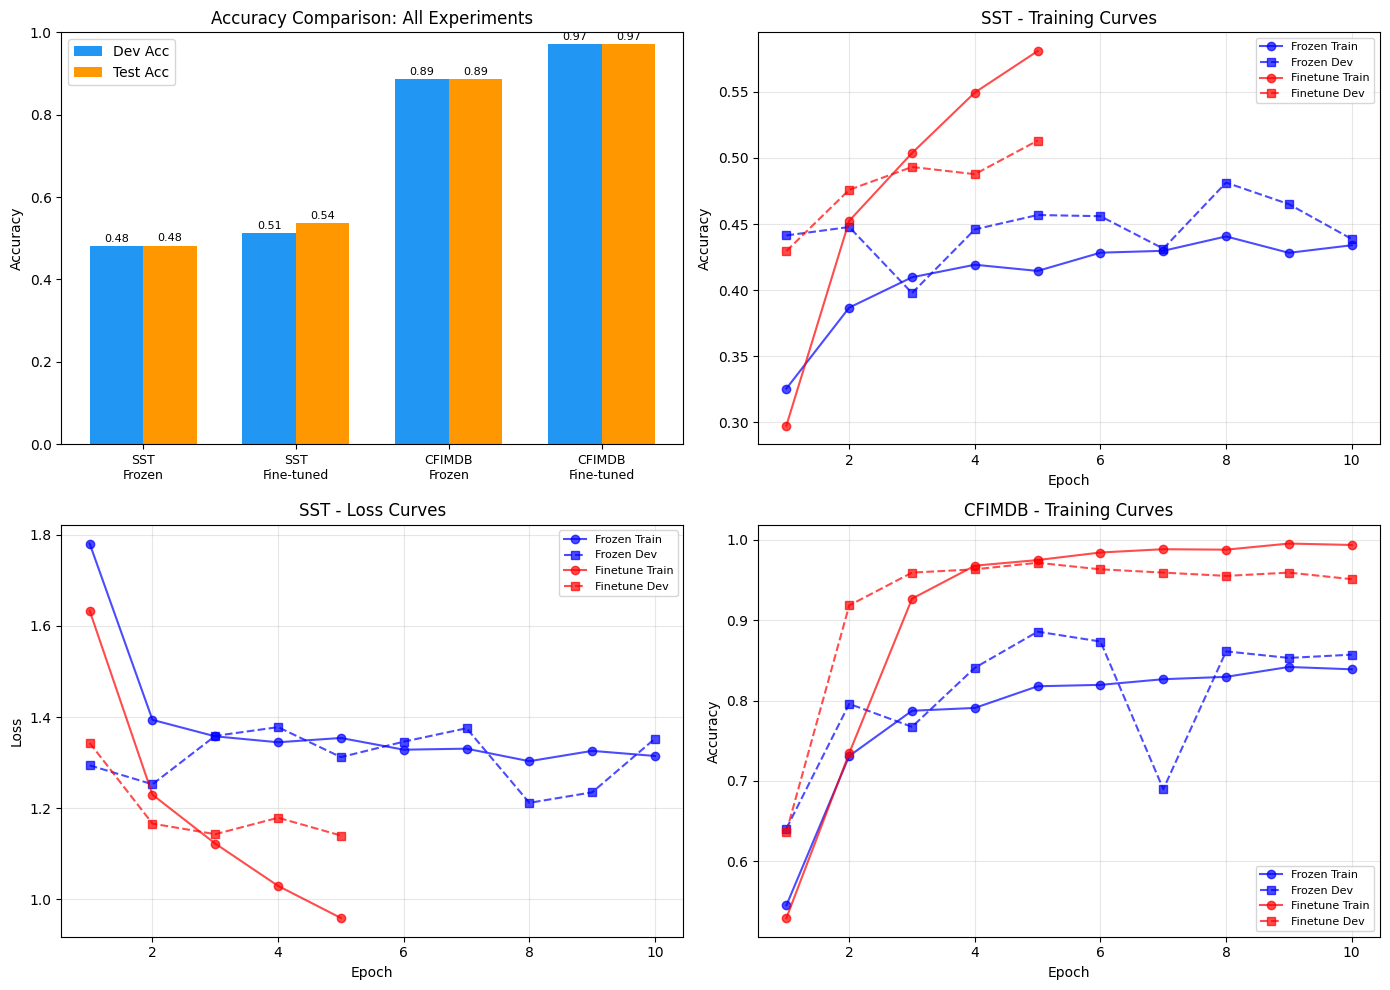

In [17]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart comparison
ax = axes[0, 0]
x = np.arange(len(results))
width = 0.35
bars1 = ax.bar(x - width/2, results['Dev Accuracy'], width, label='Dev Acc', color='#2196f3')
bars2 = ax.bar(x + width/2, results['Test Accuracy'], width, label='Test Acc', color='#ff9800')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison: All Experiments')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Dataset']}\n{row['Approach']}" for _, row in results.iterrows()], fontsize=9)
ax.legend()
ax.set_ylim(0, 1.0)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=8)

# 2. SST training curves
ax = axes[0, 1]
epochs_sst = range(1, len(sst_frozen_history['train_acc']) + 1)
ax.plot(epochs_sst, sst_frozen_history['train_acc'], 'b-o', label='Frozen Train', alpha=0.7)
ax.plot(epochs_sst, sst_frozen_history['dev_acc'], 'b--s', label='Frozen Dev', alpha=0.7)
epochs_sst_ft = range(1, len(sst_finetune_history['train_acc']) + 1)
ax.plot(epochs_sst_ft, sst_finetune_history['train_acc'], 'r-o', label='Finetune Train', alpha=0.7)
ax.plot(epochs_sst_ft, sst_finetune_history['dev_acc'], 'r--s', label='Finetune Dev', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('SST - Training Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. SST loss curves
ax = axes[1, 0]
ax.plot(epochs_sst, sst_frozen_history['train_loss'], 'b-o', label='Frozen Train', alpha=0.7)
ax.plot(epochs_sst, sst_frozen_history['dev_loss'], 'b--s', label='Frozen Dev', alpha=0.7)
ax.plot(epochs_sst_ft, sst_finetune_history['train_loss'], 'r-o', label='Finetune Train', alpha=0.7)
ax.plot(epochs_sst_ft, sst_finetune_history['dev_loss'], 'r--s', label='Finetune Dev', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('SST - Loss Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. CFIMDB training curves
ax = axes[1, 1]
epochs_cf = range(1, len(cfimdb_frozen_history['train_acc']) + 1)
ax.plot(epochs_cf, cfimdb_frozen_history['train_acc'], 'b-o', label='Frozen Train', alpha=0.7)
ax.plot(epochs_cf, cfimdb_frozen_history['dev_acc'], 'b--s', label='Frozen Dev', alpha=0.7)
epochs_cf_ft = range(1, len(cfimdb_finetune_history['train_acc']) + 1)
ax.plot(epochs_cf_ft, cfimdb_finetune_history['train_acc'], 'r-o', label='Finetune Train', alpha=0.7)
ax.plot(epochs_cf_ft, cfimdb_finetune_history['dev_acc'], 'r--s', label='Finetune Dev', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('CFIMDB - Training Curves')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## What's Next?

You've now completed both baselines! Here's what comes next:

### Your Innovation
Now you need to design and implement **your own improvement**. Some ideas:

| Idea | Complexity | Expected improvement |
|------|-----------|---------------------|
| **Attention pooling** — Learn which words matter most | Medium | +1-3% |
| **Mean pooling** — Average all token hidden states | Easy | +0-2% |
| **Multi-layer aggregation** — Combine multiple GPT-2 layers | Medium | +1-4% |
| **Adapter modules** — Lightweight trainable layers inside GPT-2 | Hard | +2-5% |
| **Ensemble** — Train 3 models and let them vote | Medium | +1-3% |
| **Data augmentation** — Create synthetic training examples | Medium | +1-3% |

### Analysis
After running all experiments, analyze:
- Which sentiment classes does the model confuse most? (confusion matrix)
- What do the training curves tell you? (overfitting? underfitting?)
- Look at specific examples where the model was wrong

### Report
Write up your findings in the provided LaTeX template (6-8 pages).

---
*End of baseline experiments. Good luck with your innovation! 🚀*